In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join('..')))

In [ ]:
import numpy as np
import pandas as pd
from src.features import cycle
from src._xgboost import search_params
from src.visualization import plot_forecast_with_train
from skforecast.recursive import ForecasterRecursive
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import joblib
import xgboost as xgb
import warnings
from skforecast.exceptions import IgnoredArgumentWarning

warnings.simplefilter('ignore', category=IgnoredArgumentWarning)

C:\Users\Ivan\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
def process_data(data: pd.DataFrame):
    df = data.copy()
    df = df.asfreq('D')
    
    df['day_of_year'] = df['Дата'].dt.dayofyear
    df = cycle(df, 'Месяц', 12)
    df = cycle(df, 'day_of_year', 365)
    
    df = df.drop(columns=['Дата'])
    
    df = df.interpolate(method='akima').ffill().bfill().round(2)
    
    return df
    
def show_results(model, df_train_full, df_test, target_col, exog_cols):
    last_window = df_train_full[target_col].iloc[-len(model.lags):]
    y_pred = model.predict(
                steps=len(df_test),
                exog=df_test[exog_cols],
                last_window = last_window
            )

    rmse = np.sqrt(mean_squared_error(df_test[target_col], y_pred))
    print(f'RMSE на тесте = {rmse}')

    plot_forecast_with_train(df_train_full[target_col], df_test[target_col], y_pred)
    
def fit_best_model(df_train, best_params, target_col, exog_cols):
    best_model = ForecasterRecursive(xgb.XGBRegressor(**best_params, random_state = 42), 
                                    lags = best_params['lags'])
    best_model.fit(
                y=df_train[target_col],
                exog=df_train[exog_cols],
            )
    return best_model

In [4]:
df_train_full = pd.read_csv('../data/processed/train_raw, ZK 68, (48-1, 48-air), 27.11.20-31.12.24.csv', parse_dates=['Дата'])
df_train_full.index = df_train_full['Дата']

df_test = pd.read_csv('../data/processed/test_raw, ZK 68, (48-1, 48-air), 01.01.25-15.12.25.csv', parse_dates=['Дата'])
df_test.index = df_test['Дата']

df_train = df_train_full[:'2023-12-31'].copy()
df_val = df_train_full['2024-01-01':].copy()

In [5]:
df_train_full = process_data(df_train_full)
df_train = process_data(df_train)
df_val = process_data(df_val)
df_test = process_data(df_test)

Глубина 0

In [6]:
depth = 0
model_path = f'../xgboost/models/xgb_v2_{depth}'
target_col = f'48-1 ({depth})'
exog_cols = ['Месяц_sin', 'Месяц_cos', 'day_of_year_sin', 'day_of_year_cos']

In [7]:
study = search_params(df_train, df_val, target_col, exog_cols=exog_cols, max_lags=5)
best_params = study.best_params
print(f'Лучшие параметры = {best_params}')
print(f'Лучший RMSE score = {study.best_value}')

[I 2026-05-13 18:56:58,111] A new study created in memory with name: no-name-7cbdf8dd-9071-4ea6-b9fb-f77519f90ce6
[I 2026-05-13 18:56:58,851] Trial 0 finished with value: 5.423960095868502 and parameters: {'lags': 5, 'n_estimators': 462, 'learning_rate': 0.0034010138447376666, 'max_depth': 8, 'subsample': 0.43330242319864287, 'colsample_bytree': 0.5615104386379992, 'colsample_bylevel': 0.45701441425139494, 'colsample_bynode': 0.8331086448781954, 'reg_alpha': 1.4948604037357599e-05, 'reg_lambda': 0.17129969946258783, 'gamma': 0.0045489722813988115, 'min_child_weight': 7, 'max_delta_step': 19}. Best is trial 0 with value: 5.423960095868502.
[I 2026-05-13 18:56:59,176] Trial 1 finished with value: 3.436861603485895 and parameters: {'lags': 1, 'n_estimators': 564, 'learning_rate': 0.018890259644963197, 'max_depth': 7, 'subsample': 0.6100390274756434, 'colsample_bytree': 0.6592660978570543, 'colsample_bylevel': 0.579160965241112, 'colsample_bynode': 0.9210237570260763, 'reg_alpha': 0.000547

Лучшие параметры = {'lags': 5, 'n_estimators': 343, 'learning_rate': 0.057335166811507014, 'max_depth': 2, 'subsample': 0.9450143780972627, 'colsample_bytree': 0.4317377924303939, 'colsample_bylevel': 0.6647991809668394, 'colsample_bynode': 0.754970023931053, 'reg_alpha': 8.035849965921889e-05, 'reg_lambda': 0.5524571808361625, 'gamma': 5.3020986062962515e-05, 'min_child_weight': 6, 'max_delta_step': 4}
Лучший RMSE score = 3.224836914686701


In [8]:
best_model = fit_best_model(df_train, best_params, target_col, exog_cols)
joblib.dump(best_model, model_path)

['../xgboost/models/xgb_v2_0']

RMSE на тесте = 2.6859505492901468


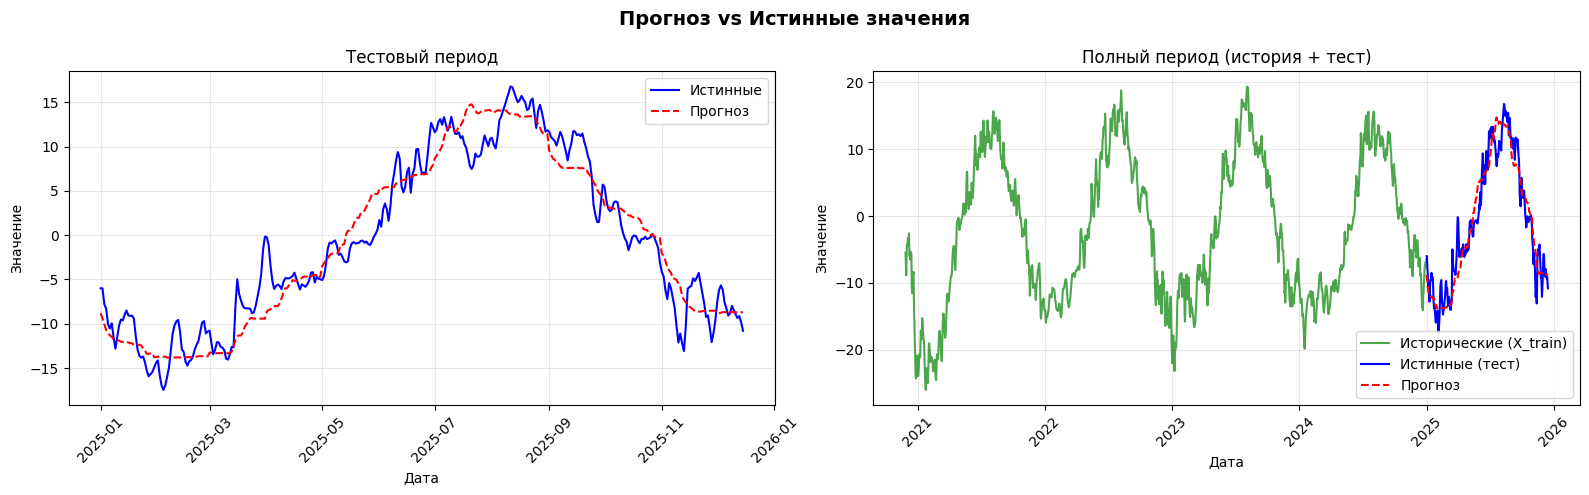

,feature,importance
2,lag_3,0.236840
8,day_of_year_cos,0.179887
4,lag_5,0.154123
6,Месяц_cos,0.117486
0,lag_1,0.107643
1,lag_2,0.097847
3,lag_4,0.058156
7,day_of_year_sin,0.043630
5,Месяц_sin,0.004388


In [9]:
model = joblib.load(model_path)
show_results(model, df_train_full, df_test, target_col, exog_cols)
importances = model.get_feature_importances()
importances

Глубина 3

In [10]:
depth = 3
model_path = f'../xgboost/models/xgb_v2_{depth}'
target_col = f'48-1 ({depth})'
exog_cols = ['Месяц_sin', 'Месяц_cos', 'day_of_year_sin', 'day_of_year_cos']

In [11]:
study = search_params(df_train, df_val, target_col, exog_cols=exog_cols, max_lags=5)
best_params = study.best_params
print(f'Лучшие параметры = {best_params}')
print(f'Лучший RMSE score = {study.best_value}')

[I 2026-05-13 18:57:17,912] A new study created in memory with name: no-name-bd18b7a8-33fd-4dcf-8d2b-03e17a3f53c3
[I 2026-05-13 18:57:18,235] Trial 0 finished with value: 2.3463029842875778 and parameters: {'lags': 5, 'n_estimators': 447, 'learning_rate': 0.0017073360435892052, 'max_depth': 2, 'subsample': 0.5631092861600975, 'colsample_bytree': 0.5594778082581617, 'colsample_bylevel': 0.681934236824991, 'colsample_bynode': 0.5025934703840432, 'reg_alpha': 0.07449576879015382, 'reg_lambda': 0.42847709758322255, 'gamma': 0.00017671783785815914, 'min_child_weight': 15, 'max_delta_step': 9}. Best is trial 0 with value: 2.3463029842875778.
[I 2026-05-13 18:57:18,843] Trial 1 finished with value: 1.0827150555927285 and parameters: {'lags': 4, 'n_estimators': 566, 'learning_rate': 0.004323984713894306, 'max_depth': 8, 'subsample': 0.43327355344412716, 'colsample_bytree': 0.5351197265409761, 'colsample_bylevel': 0.9064754782702482, 'colsample_bynode': 0.5005830554276852, 'reg_alpha': 0.031913

Лучшие параметры = {'lags': 1, 'n_estimators': 546, 'learning_rate': 0.11096615451078157, 'max_depth': 3, 'subsample': 0.757799147969382, 'colsample_bytree': 0.6529198869533346, 'colsample_bylevel': 0.7069954605272915, 'colsample_bynode': 0.9626579384453037, 'reg_alpha': 0.19323114894346377, 'reg_lambda': 1.5439885223368036e-05, 'gamma': 0.008268144963472683, 'min_child_weight': 13, 'max_delta_step': 15}
Лучший RMSE score = 0.7809616464637923


In [12]:
best_model = fit_best_model(df_train, best_params, target_col, exog_cols)
joblib.dump(best_model, model_path)

['../xgboost/models/xgb_v2_3']

RMSE на тесте = 0.7676687504994861


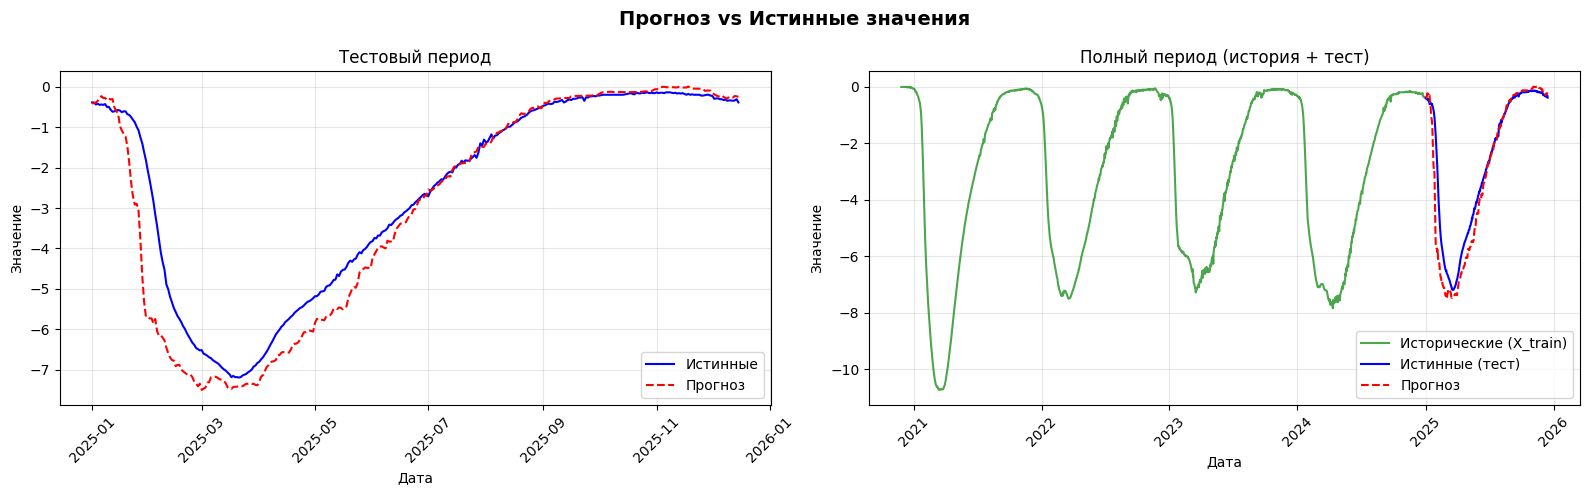

,feature,importance
0,lag_1,0.314238
1,Месяц_sin,0.306708
3,day_of_year_sin,0.286424
2,Месяц_cos,0.061575
4,day_of_year_cos,0.031055


In [13]:
model = joblib.load(model_path)
show_results(model, df_train_full, df_test, target_col, exog_cols)
importances = model.get_feature_importances()
importances

Глубина 5

In [14]:
depth = 5
model_path = f'../xgboost/models/xgb_v2_{depth}'
target_col = f'48-1 ({depth})'
exog_cols = ['Месяц_sin', 'Месяц_cos', 'day_of_year_sin', 'day_of_year_cos']

In [15]:
study = search_params(df_train, df_val, target_col, exog_cols=exog_cols, max_lags=5)
best_params = study.best_params
print(f'Лучшие параметры = {best_params}')
print(f'Лучший RMSE score = {study.best_value}')

[I 2026-05-13 18:57:37,249] A new study created in memory with name: no-name-489873af-bcbb-4e8d-a4e7-97a8d0a1b476
[I 2026-05-13 18:57:37,529] Trial 0 finished with value: 2.0138316543517774 and parameters: {'lags': 3, 'n_estimators': 606, 'learning_rate': 0.0005307636644692453, 'max_depth': 1, 'subsample': 0.8038863327431869, 'colsample_bytree': 0.47390602010285005, 'colsample_bylevel': 0.40870640107999173, 'colsample_bynode': 0.4728101080395274, 'reg_alpha': 0.4911012188602701, 'reg_lambda': 1.1579454714744715, 'gamma': 1.1800921909142929e-05, 'min_child_weight': 12, 'max_delta_step': 13}. Best is trial 0 with value: 2.0138316543517774.
[I 2026-05-13 18:57:37,877] Trial 1 finished with value: 1.8389449325537672 and parameters: {'lags': 2, 'n_estimators': 961, 'learning_rate': 0.2686046899740178, 'max_depth': 2, 'subsample': 0.4162609482537979, 'colsample_bytree': 0.9431396699271947, 'colsample_bylevel': 0.8901637409701068, 'colsample_bynode': 0.5874456675839337, 'reg_alpha': 2.6244004

Лучшие параметры = {'lags': 3, 'n_estimators': 828, 'learning_rate': 0.11305418613739909, 'max_depth': 4, 'subsample': 0.6428722836421743, 'colsample_bytree': 0.7419625760604196, 'colsample_bylevel': 0.9521417399337557, 'colsample_bynode': 0.8265398917273561, 'reg_alpha': 0.3489063794622153, 'reg_lambda': 2.3468732376754833, 'gamma': 0.0011113186584011422, 'min_child_weight': 11, 'max_delta_step': 7}
Лучший RMSE score = 0.6123626001324625


In [16]:
best_model = fit_best_model(df_train, best_params, target_col, exog_cols)
joblib.dump(best_model, model_path)

['../xgboost/models/xgb_v2_5']

RMSE на тесте = 0.5106800865728343


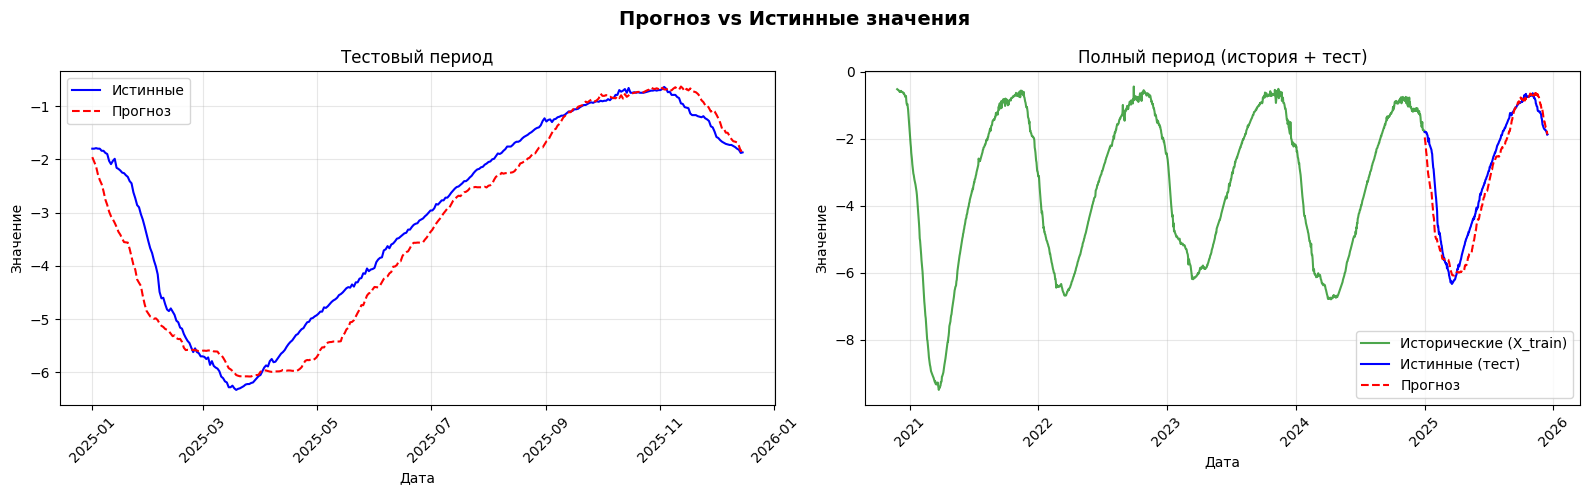

,feature,importance
1,lag_2,0.315627
0,lag_1,0.300287
5,day_of_year_sin,0.174429
3,Месяц_sin,0.144923
2,lag_3,0.060757
4,Месяц_cos,0.002672
6,day_of_year_cos,0.001306


In [17]:
model = joblib.load(model_path)
show_results(model, df_train_full, df_test, target_col, exog_cols)
importances = model.get_feature_importances()
importances

Глубина 7

In [18]:
depth = 7
model_path = f'../xgboost/models/xgb_v2_{depth}'
target_col = f'48-1 ({depth})'
exog_cols = ['Месяц_sin', 'Месяц_cos', 'day_of_year_sin', 'day_of_year_cos']

In [19]:
study = search_params(df_train, df_val, target_col, exog_cols=exog_cols, max_lags=5)
best_params = study.best_params
print(f'Лучшие параметры = {best_params}')
print(f'Лучший RMSE score = {study.best_value}')

[I 2026-05-13 18:58:01,718] A new study created in memory with name: no-name-b14baf92-7cd9-4f48-b8eb-48eeb735c4dc
[I 2026-05-13 18:58:02,283] Trial 0 finished with value: 0.6430262465974222 and parameters: {'lags': 3, 'n_estimators': 671, 'learning_rate': 0.012299362169019267, 'max_depth': 6, 'subsample': 0.7298946145283021, 'colsample_bytree': 0.5345681213381104, 'colsample_bylevel': 0.4401877361090303, 'colsample_bynode': 0.7439993532469548, 'reg_alpha': 0.02683603618822785, 'reg_lambda': 2.2661168636220374e-05, 'gamma': 0.019339440776695586, 'min_child_weight': 9, 'max_delta_step': 3}. Best is trial 0 with value: 0.6430262465974222.
[I 2026-05-13 18:58:02,582] Trial 1 finished with value: 0.9352722037543153 and parameters: {'lags': 3, 'n_estimators': 326, 'learning_rate': 0.13196185448150838, 'max_depth': 5, 'subsample': 0.8522379203795094, 'colsample_bytree': 0.4734681331427959, 'colsample_bylevel': 0.7029738263658231, 'colsample_bynode': 0.6803573881454233, 'reg_alpha': 0.00861678

Лучшие параметры = {'lags': 3, 'n_estimators': 894, 'learning_rate': 0.09307008542873733, 'max_depth': 8, 'subsample': 0.5976043514662965, 'colsample_bytree': 0.808534743803015, 'colsample_bylevel': 0.7717864838827134, 'colsample_bynode': 0.8049592216225773, 'reg_alpha': 0.04497731113899551, 'reg_lambda': 0.01659058442295729, 'gamma': 0.014457765717235276, 'min_child_weight': 2, 'max_delta_step': 10}
Лучший RMSE score = 0.5510349590647999


In [20]:
best_model = fit_best_model(df_train, best_params, target_col, exog_cols)
joblib.dump(best_model, model_path)

['../xgboost/models/xgb_v2_7']

RMSE на тесте = 0.43322011883505196


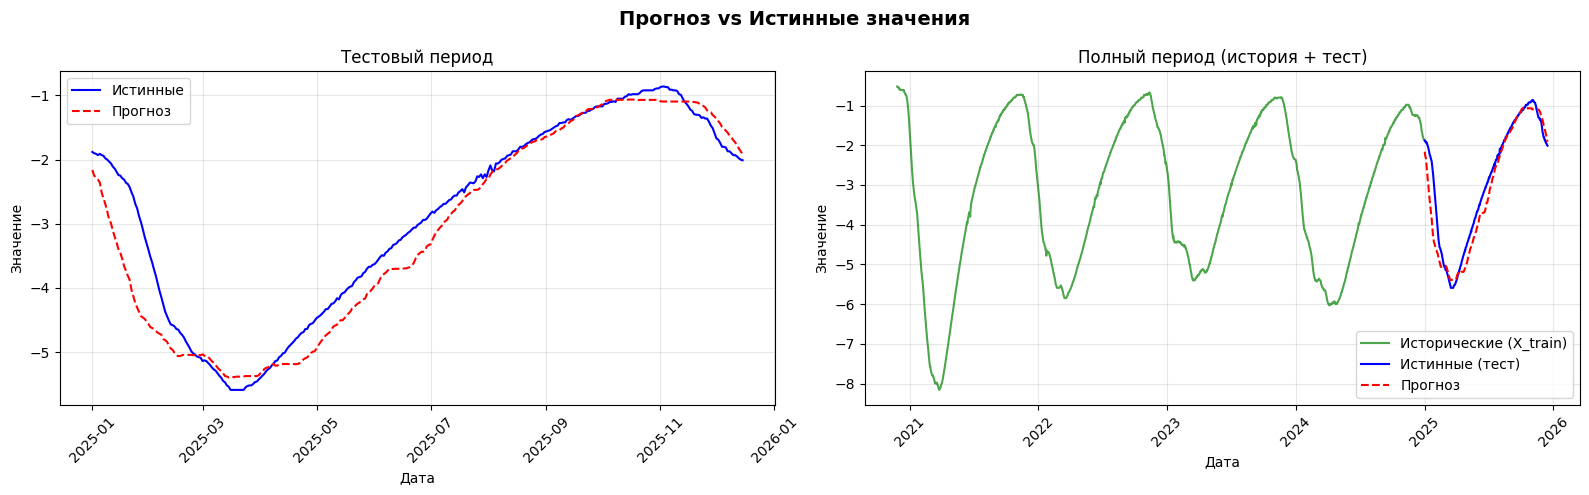

,feature,importance
3,Месяц_sin,0.396650
2,lag_3,0.247568
0,lag_1,0.154260
1,lag_2,0.090137
5,day_of_year_sin,0.078834
4,Месяц_cos,0.018590
6,day_of_year_cos,0.013961


In [21]:
model = joblib.load(model_path)
show_results(model, df_train_full, df_test, target_col, exog_cols)
importances = model.get_feature_importances()
importances

Глубина 10

In [22]:
depth = 10
model_path = f'../xgboost/models/xgb_v2_{depth}'
target_col = f'48-1 ({depth})'
exog_cols = ['Месяц_sin', 'Месяц_cos', 'day_of_year_sin', 'day_of_year_cos']

In [23]:
study = search_params(df_train, df_val, target_col, exog_cols=exog_cols, max_lags=5)
best_params = study.best_params
print(f'Лучшие параметры = {best_params}')
print(f'Лучший RMSE score = {study.best_value}')

[I 2026-05-13 18:58:15,223] A new study created in memory with name: no-name-3498dc9b-189f-450e-a870-dbda92a667f6
[I 2026-05-13 18:58:15,638] Trial 0 finished with value: 0.4164347597989999 and parameters: {'lags': 4, 'n_estimators': 909, 'learning_rate': 0.017403263634379773, 'max_depth': 4, 'subsample': 0.6458464780093052, 'colsample_bytree': 0.4943577361157445, 'colsample_bylevel': 0.9716716665629446, 'colsample_bynode': 0.7630679095199393, 'reg_alpha': 0.00022231062822363992, 'reg_lambda': 1.3356153579551788, 'gamma': 0.2524361260158144, 'min_child_weight': 12, 'max_delta_step': 5}. Best is trial 0 with value: 0.4164347597989999.
[I 2026-05-13 18:58:15,970] Trial 1 finished with value: 0.5735338312551065 and parameters: {'lags': 5, 'n_estimators': 400, 'learning_rate': 0.006732697808307905, 'max_depth': 4, 'subsample': 0.5682406288164781, 'colsample_bytree': 0.8325062347292199, 'colsample_bylevel': 0.47077591099352306, 'colsample_bynode': 0.9826298217057952, 'reg_alpha': 0.06142042

Лучшие параметры = {'lags': 4, 'n_estimators': 909, 'learning_rate': 0.017403263634379773, 'max_depth': 4, 'subsample': 0.6458464780093052, 'colsample_bytree': 0.4943577361157445, 'colsample_bylevel': 0.9716716665629446, 'colsample_bynode': 0.7630679095199393, 'reg_alpha': 0.00022231062822363992, 'reg_lambda': 1.3356153579551788, 'gamma': 0.2524361260158144, 'min_child_weight': 12, 'max_delta_step': 5}
Лучший RMSE score = 0.4164347597989999


In [24]:
best_model = fit_best_model(df_train, best_params, target_col, exog_cols)
joblib.dump(best_model, model_path)

['../xgboost/models/xgb_v2_10']

RMSE на тесте = 0.20670624158482992


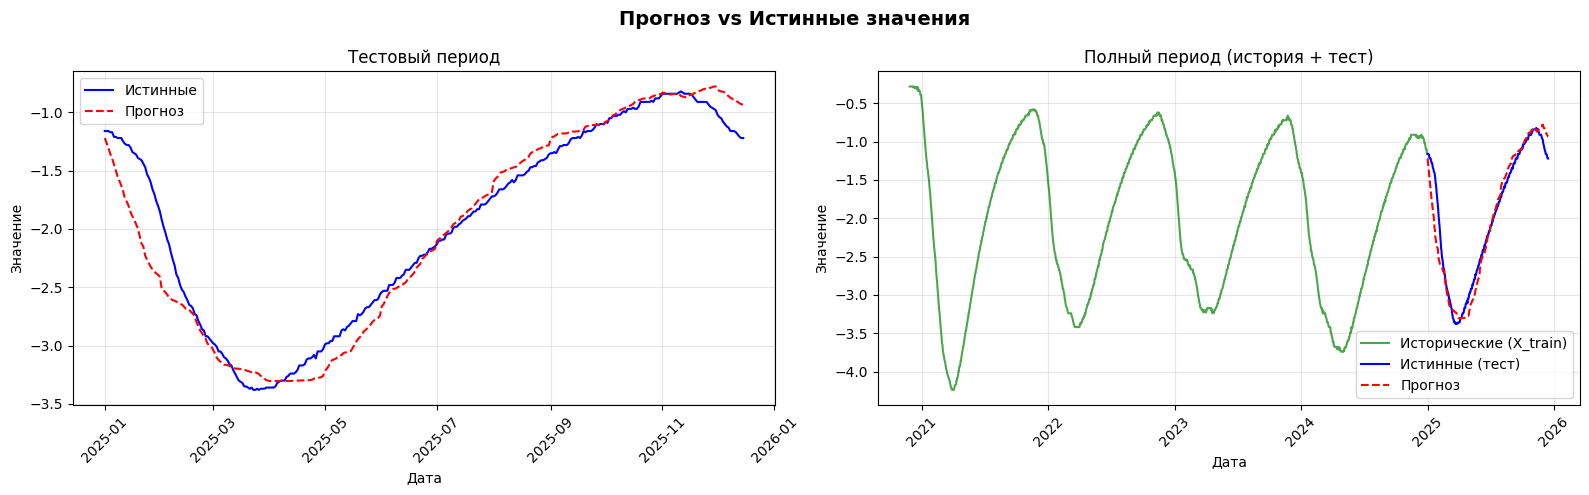

,feature,importance
6,day_of_year_sin,0.205728
2,lag_3,0.199851
0,lag_1,0.154713
4,Месяц_sin,0.144105
3,lag_4,0.120974
1,lag_2,0.100878
7,day_of_year_cos,0.038946
5,Месяц_cos,0.034805


In [25]:
model = joblib.load(model_path)
show_results(model, df_train_full, df_test, target_col, exog_cols)
importances = model.get_feature_importances()
importances